In [1]:
import pandas as pd
import re
import numpy as np

# Load the CSV file
df = pd.read_csv('rent.csv')
df

,Price,Pid,Property_name,Address
0,"400,000 / year",H1190,1 bedroom mini flat Flat / Apartment for rent ...,Fidiso Estate Abijo Ajah Lagos
1,"14,000,000 / year",G7398,3 bedroom Flat / Apartment for rent Gerrard Ge...,Gerrard Gerrard Gerard Road Ikoyi Lagos
2,"200,000 / year",H5843,1 bedroom mini flat Flat / Apartment for rent ...,Obadia Akoka Yaba Lagos
3,"800,000 / year",H1194,2 bedroom Flat / Apartment for rent Iju Ishaga...,surulere Iju Ishaga Road Gbaja Surulere Lagos
4,"300,000 / year",H5842,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba Lagos
...,...,...,...,...
9848,"400,000 / year",F1443,1 bedroom mini flat Flat / Apartment for rent ...,Alagomeji Alagomeji Yaba Lagos
9849,"800,000",F1442,3 bedroom Flat / Apartment for rent Onike Yaba...,iwaya road Onike Yaba Lagos
9850,"1,000,000 / year",F1441,2 bedroom Flat / Apartment for rent Adekunle Y...,Herbert Macaulay way Adekunle Yaba Lagos
9851,"1,500,000",F1433,3 bedroom Duplex for rent Off Chief Echegile S...,Off Chief Echegile Street Ogudu Orike Ogudu Lagos


In [2]:
print(df.iloc[1,2])

3 bedroom Flat / Apartment for rent Gerrard Gerard road Ikoyi Lagos


In [3]:
# Check columns, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9853 entries, 0 to 9852
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Price          9853 non-null   object
 1   Pid            9853 non-null   object
 2   Property_name  9853 non-null   object
 3   Address        9853 non-null   object
dtypes: object(4)
memory usage: 308.0+ KB


In [4]:
# Basic statistics
df.describe()

,Price,Pid,Property_name,Address
count,9853,9853,9853,9853
unique,388,9850,4762,5945
top,"1,000,000",G0258,3 bedroom Flat / Apartment for rent Lekki Phas...,Akoka Akoka Yaba Lagos
freq,289,2,103,122


In [5]:
no_bedroom_mask = ~df['Property_name'].str.contains(r'\d+\s*bedroom', case=False, na=False)
non_bedroom_rows = df[no_bedroom_mask]
non_bedroom_rows

,Price,Pid,Property_name,Address
6,"300,000 / year",H5142,Self Contain for rent Akoka Abule-Oja Yaba Lagos,Yaba Akoka Abule Oja Yaba Lagos
11,"7,000",H5831,Shop for rent Fola Agoro Yaba Lagos,Fola Agoro Fola Agoro Yaba Lagos
13,"500,000",H5826,Office Space for rent GRA Phase 2 Beside Karis...,GRA Phase 2 Beside Karis school Magodo Kosofe ...
27,"1,500,000 / year",H5778,300.0 square meter Flat / Apartment for rent A...,Alagomeji Alagomeji Yaba Lagos
37,"250,000 / year",H5751,Flat / Apartment for rent Shomolu Shomolu Lagos,off Bajulaiye road Shomolu Shomolu Lagos
...,...,...,...,...
9808,"2,000,000 / year","95,F1643",95.0 square meter Office Space for rent Opebi ...,igbasan street Opebi Ikeja Lagos
9820,"250,000,000",F1561,1500.0 square meter Land for rent Victoria Isl...,Oniru Victoria Island Extension Victoria Islan...
9823,"140,000,000",F1557,600.0 square meter Land for rent Lekki Phase 1...,lekki phase 1 Lekki Phase 1 Lekki Lagos
9837,"30,000 / sqm","355,F1466",355.0 square meter Office Space for rent Marin...,Marina Marina Marina Lagos Island Lagos


In [6]:
non_bedroom_rows.iloc[0:60,2]

6       Self Contain for rent Akoka Abule-Oja Yaba Lagos
11                   Shop for rent Fola Agoro Yaba Lagos
13     Office Space for rent GRA Phase 2 Beside Karis...
27     300.0 square meter Flat / Apartment for rent A...
37       Flat / Apartment for rent Shomolu Shomolu Lagos
41           Self Contain for rent Shomolu Shomolu Lagos
43     Flat / Apartment for rent Adeola Odeku Victori...
48                        Shop for rent Akoka Yaba Lagos
73            Self Contain for rent Abule-Oja Yaba Lagos
74            Self Contain for rent Abule-Oja Yaba Lagos
79            Self Contain for rent Abule-Oja Yaba Lagos
151    Office Space for rent 1004 Ligali Ayorinde Vic...
152                  Shop for rent Shomolu Shomolu Lagos
153                  Shop for rent Shomolu Shomolu Lagos
154                  Shop for rent Fola Agoro Yaba Lagos
155                  Shop for rent Fola Agoro Yaba Lagos
158          Duplex for rent Oniru Victoria Island Lagos
162    Office Space for rent Of

In [7]:
#mport pandas as pd
#import numpy as np

# extract number before "bedroom"
bedroom_numbers = df['Property_name'].str.extract(r'(\d+)\s*bedroom', flags=re.IGNORECASE)

df['Bedrooms'] = np.where(
    bedroom_numbers[0].notna(),
    bedroom_numbers[0],  # case 1: has number of bedrooms
    np.where(
        df['Property_name'].str.contains('self contain', case=False, na=False),
        'self contain',  # case 2: self contain
        'commercial/incomplete data'  # case 3: everything else
    )
)
df

,Price,Pid,Property_name,Address,Bedrooms
0,"400,000 / year",H1190,1 bedroom mini flat Flat / Apartment for rent ...,Fidiso Estate Abijo Ajah Lagos,1
1,"14,000,000 / year",G7398,3 bedroom Flat / Apartment for rent Gerrard Ge...,Gerrard Gerrard Gerard Road Ikoyi Lagos,3
2,"200,000 / year",H5843,1 bedroom mini flat Flat / Apartment for rent ...,Obadia Akoka Yaba Lagos,1
3,"800,000 / year",H1194,2 bedroom Flat / Apartment for rent Iju Ishaga...,surulere Iju Ishaga Road Gbaja Surulere Lagos,2
4,"300,000 / year",H5842,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba Lagos,1
...,...,...,...,...,...
9848,"400,000 / year",F1443,1 bedroom mini flat Flat / Apartment for rent ...,Alagomeji Alagomeji Yaba Lagos,1
9849,"800,000",F1442,3 bedroom Flat / Apartment for rent Onike Yaba...,iwaya road Onike Yaba Lagos,3
9850,"1,000,000 / year",F1441,2 bedroom Flat / Apartment for rent Adekunle Y...,Herbert Macaulay way Adekunle Yaba Lagos,2
9851,"1,500,000",F1433,3 bedroom Duplex for rent Off Chief Echegile S...,Off Chief Echegile Street Ogudu Orike Ogudu Lagos,3


In [8]:
df['Bedrooms'].value_counts()

Bedrooms
3                             3967
2                             1750
4                             1207
1                             1156
commercial/incomplete data     790
5                              593
self contain                   232
6                               67
7                               38
10                              35
8                               14
9                                4
Name: count, dtype: int64

In [9]:
# checking rows that has the commercial or incomplete data

rows_ci = df[df['Bedrooms'] == 'commercial/incomplete data']
rows_ci

,Price,Pid,Property_name,Address,Bedrooms
11,"7,000",H5831,Shop for rent Fola Agoro Yaba Lagos,Fola Agoro Fola Agoro Yaba Lagos,commercial/incomplete data
13,"500,000",H5826,Office Space for rent GRA Phase 2 Beside Karis...,GRA Phase 2 Beside Karis school Magodo Kosofe ...,commercial/incomplete data
27,"1,500,000 / year",H5778,300.0 square meter Flat / Apartment for rent A...,Alagomeji Alagomeji Yaba Lagos,commercial/incomplete data
37,"250,000 / year",H5751,Flat / Apartment for rent Shomolu Shomolu Lagos,off Bajulaiye road Shomolu Shomolu Lagos,commercial/incomplete data
43,"5,000,000",H1845,Flat / Apartment for rent Adeola Odeku Victori...,Adeola Odeku street Adeola Odeku Victoria Isl...,commercial/incomplete data
...,...,...,...,...,...
9782,"20,000 / sqm","70,F1808",Office Space for rent Off Awolowo Road Ikoyi L...,Off Awolowo Road Ikoyi Lagos,commercial/incomplete data
9808,"2,000,000 / year","95,F1643",95.0 square meter Office Space for rent Opebi ...,igbasan street Opebi Ikeja Lagos,commercial/incomplete data
9820,"250,000,000",F1561,1500.0 square meter Land for rent Victoria Isl...,Oniru Victoria Island Extension Victoria Islan...,commercial/incomplete data
9823,"140,000,000",F1557,600.0 square meter Land for rent Lekki Phase 1...,lekki phase 1 Lekki Phase 1 Lekki Lagos,commercial/incomplete data


In [10]:
# sample of the commercial or incomplete data

rows_ci.iloc[5:65,2]

48                        Shop for rent Akoka Yaba Lagos
151    Office Space for rent 1004 Ligali Ayorinde Vic...
152                  Shop for rent Shomolu Shomolu Lagos
153                  Shop for rent Shomolu Shomolu Lagos
154                  Shop for rent Fola Agoro Yaba Lagos
155                  Shop for rent Fola Agoro Yaba Lagos
158          Duplex for rent Oniru Victoria Island Lagos
162    Office Space for rent Off medical road, Obafem...
163      Office Space for rent GRA Ikeja GRA Ikeja Lagos
164          Office Space for rent Ikeja GRA Ikeja Lagos
169       Office Space for rent Awolowo Road Ikoyi Lagos
193    Flat / Apartment for rent Adeola Odeku Victori...
203    Land for rent Off Lekki-Epe Expressway Ajah Lagos
207    Commercial Property for rent Shomolu Shomolu L...
219    90.0 square meter Commercial Property for rent...
240                  Shop for rent Shomolu Shomolu Lagos
260    170.0 square meter Commercial Property for ren...
284            Bungalow for ren

In [11]:
# dropping rows of commercial or incomplete data

df = df.drop(df[df['Bedrooms'] == 'commercial/incomplete data'].index).reset_index(drop=True)
df

,Price,Pid,Property_name,Address,Bedrooms
0,"400,000 / year",H1190,1 bedroom mini flat Flat / Apartment for rent ...,Fidiso Estate Abijo Ajah Lagos,1
1,"14,000,000 / year",G7398,3 bedroom Flat / Apartment for rent Gerrard Ge...,Gerrard Gerrard Gerard Road Ikoyi Lagos,3
2,"200,000 / year",H5843,1 bedroom mini flat Flat / Apartment for rent ...,Obadia Akoka Yaba Lagos,1
3,"800,000 / year",H1194,2 bedroom Flat / Apartment for rent Iju Ishaga...,surulere Iju Ishaga Road Gbaja Surulere Lagos,2
4,"300,000 / year",H5842,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba Lagos,1
...,...,...,...,...,...
9058,"400,000 / year",F1443,1 bedroom mini flat Flat / Apartment for rent ...,Alagomeji Alagomeji Yaba Lagos,1
9059,"800,000",F1442,3 bedroom Flat / Apartment for rent Onike Yaba...,iwaya road Onike Yaba Lagos,3
9060,"1,000,000 / year",F1441,2 bedroom Flat / Apartment for rent Adekunle Y...,Herbert Macaulay way Adekunle Yaba Lagos,2
9061,"1,500,000",F1433,3 bedroom Duplex for rent Off Chief Echegile S...,Off Chief Echegile Street Ogudu Orike Ogudu Lagos,3


In [12]:
df['Bedrooms'].value_counts()

Bedrooms
3               3967
2               1750
4               1207
1               1156
5                593
self contain     232
6                 67
7                 38
10                35
8                 14
9                  4
Name: count, dtype: int64

In [13]:
# making self contain to be 0 as the number of bedroom

df['Bedrooms'] = pd.to_numeric(df['Bedrooms'].replace('self contain', 0))
df['Bedrooms'].value_counts()

Bedrooms
3     3967
2     1750
4     1207
1     1156
5      593
0      232
6       67
7       38
10      35
8       14
9        4
Name: count, dtype: int64

In [14]:
# Extract the word before 'lagos' and create a new column named Locality
# Creating a new column called Locality 

df['Locality'] = df['Address'].str.extract(r'(\w+)\s+Lagos\s*$', flags=re.IGNORECASE)
df

,Price,Pid,Property_name,Address,Bedrooms,Locality
0,"400,000 / year",H1190,1 bedroom mini flat Flat / Apartment for rent ...,Fidiso Estate Abijo Ajah Lagos,1,Ajah
1,"14,000,000 / year",G7398,3 bedroom Flat / Apartment for rent Gerrard Ge...,Gerrard Gerrard Gerard Road Ikoyi Lagos,3,Ikoyi
2,"200,000 / year",H5843,1 bedroom mini flat Flat / Apartment for rent ...,Obadia Akoka Yaba Lagos,1,Yaba
3,"800,000 / year",H1194,2 bedroom Flat / Apartment for rent Iju Ishaga...,surulere Iju Ishaga Road Gbaja Surulere Lagos,2,Surulere
4,"300,000 / year",H5842,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba Lagos,1,Yaba
...,...,...,...,...,...,...
9058,"400,000 / year",F1443,1 bedroom mini flat Flat / Apartment for rent ...,Alagomeji Alagomeji Yaba Lagos,1,Yaba
9059,"800,000",F1442,3 bedroom Flat / Apartment for rent Onike Yaba...,iwaya road Onike Yaba Lagos,3,Yaba
9060,"1,000,000 / year",F1441,2 bedroom Flat / Apartment for rent Adekunle Y...,Herbert Macaulay way Adekunle Yaba Lagos,2,Yaba
9061,"1,500,000",F1433,3 bedroom Duplex for rent Off Chief Echegile S...,Off Chief Echegile Street Ogudu Orike Ogudu Lagos,3,Ogudu


In [15]:
df['Locality'].unique()

array(['Ajah', 'Ikoyi', 'Yaba', 'Surulere', 'Ikosi', 'Shomolu', 'Ilupeju',
       'Lekki', 'Odofin', 'Gbagada', 'Ikeja', 'Isolo', 'Ogba', 'Ikorodu',
       'Ojodu', 'Mushin', 'Island', 'Ogudu', 'Maryland', 'Sangotedo',
       'Alimosho', 'Okota', 'Idimu', 'Agege', 'Egba', 'Ojota', 'Ipaja',
       'Igando', 'Orile', 'Oshodi', 'Apapa', '1', 'Kosofe', 'Ejigbo',
       'Badagry', 'Lagos', 'Ojo', 'Berger', 'Ketu'], dtype=object)

In [16]:
# there are wrong data in locality: island, '1', lagos. these are not locality

# fixing wrong data in locality

df[df['Locality'] == '1']

,Price,Pid,Property_name,Address,Bedrooms,Locality
1831,"3,000,000 / year",H2566,4 bedroom Flat / Apartment for rent Lekki Peni...,Hakeem Dickson Street Lekki Peninsula Estate ...,4,1


In [17]:
df.iloc[1803,3]

'opposite Fara park Estate Sangotedo Ajah Lagos'

In [18]:
df['Locality'] = df['Locality'].replace('1', 'lekki')
df.iloc[1803,5]

'Ajah'

In [19]:
df[df['Locality'] == 'Lagos']

,Price,Pid,Property_name,Address,Bedrooms,Locality
3599,"550,000 / year",G8154,3 bedroom Flat / Apartment for rent Lagos,Amule Ipaja Lagos Lagos,3,Lagos


In [20]:
df.iloc[3529,3]

'Berger Ojodu Lagos'

In [21]:
df['Locality'] = df['Locality'].replace('Lagos', 'Ipaja')
df.iloc[3529,5]

'Ojodu'

In [22]:
row_island = df[df['Locality'] == 'Island']
row_island

,Price,Pid,Property_name,Address,Bedrooms,Locality
122,"4,500,000 / year",H5671,3 bedroom Flat / Apartment for rent Oniru Vict...,Off Palace Way Oniru Victoria Island Extension...,3,Island
125,"4,500,000 / year",H5668,3 bedroom Flat / Apartment for rent Oniru Vict...,off Palace Way Oniru Victoria Island Extension...,3,Island
151,"3,000,000",H5615,2 bedroom Flat / Apartment for rent Oniru Adem...,Oniru Ademola Adetokunbo Victoria Island Lagos,2,Island
162,"7,000,000",H5597,4 bedroom Flat / Apartment for rent by Dideolu...,by Dideolu Estate Victoria Island Lagos,4,Island
165,"4,000,000 / year",H3249,3 bedroom House for rent Private estate in Vic...,Private estate in Victoria Island Private esta...,3,Island
...,...,...,...,...,...,...
8973,"2,300,000 / year",F1883,2 bedroom Flat / Apartment for rent Victoria I...,"Oniru, VI Victoria Island Extension Victoria I...",2,Island
8998,"7,000,000 / year",F1779,5 bedroom Duplex for rent Victoria Island Exte...,Oniru Palace road Victoria Island Extension Vi...,5,Island
9012,"4,500,000 / year",F1716,4 bedroom Flat / Apartment for rent Victoria I...,Oniru Victoria Island Extension Victoria Islan...,4,Island
9033,"2,500,000 / year",F1559,2 bedroom Flat / Apartment for rent ONIRU ESTA...,OFF PALACE ROAD ONIRU ESTATE Victoria Island E...,2,Island


In [23]:
row_island.iloc[1:60,3]

125     off Palace Way Oniru Victoria Island Extension...
151        Oniru Ademola Adetokunbo Victoria Island Lagos
162               by Dideolu Estate Victoria Island Lagos
165     Private estate in Victoria Island Private esta...
168                  Dideolu Estate Victoria Island Lagos
182                    Karimu Kotun Victoria Island Lagos
191        Elsie Femi Pearse Street Victoria Island Lagos
280     31A OJU OLOBUN STREET BIshop Oluwole Ahmadu Be...
282         Oju Olobun Adeola Odeku Victoria Island Lagos
295     Oniru Victoria Island Extension Victoria Islan...
306       Idejo Street Adeola Odeku Victoria Island Lagos
357                  Cluster C 1004 Victoria Island Lagos
365     victoria Island off Ajose adeogun, V.I Victori...
374     Atlantic Beach Estate Oniru Victoria Island Ex...
375     Oniru Estate Oniru Victoria Island Extension V...
377     New Market Road Onru Victoria Island Extension...
431     Bishop Aboyade Cole Street Ademola Adetokunbo ...
441           

In [24]:
df['Locality'] = df['Locality'].replace('Island', 'Victoria island')
df[df['Locality'] == 'Victoria island']

,Price,Pid,Property_name,Address,Bedrooms,Locality
122,"4,500,000 / year",H5671,3 bedroom Flat / Apartment for rent Oniru Vict...,Off Palace Way Oniru Victoria Island Extension...,3,Victoria island
125,"4,500,000 / year",H5668,3 bedroom Flat / Apartment for rent Oniru Vict...,off Palace Way Oniru Victoria Island Extension...,3,Victoria island
151,"3,000,000",H5615,2 bedroom Flat / Apartment for rent Oniru Adem...,Oniru Ademola Adetokunbo Victoria Island Lagos,2,Victoria island
162,"7,000,000",H5597,4 bedroom Flat / Apartment for rent by Dideolu...,by Dideolu Estate Victoria Island Lagos,4,Victoria island
165,"4,000,000 / year",H3249,3 bedroom House for rent Private estate in Vic...,Private estate in Victoria Island Private esta...,3,Victoria island
...,...,...,...,...,...,...
8973,"2,300,000 / year",F1883,2 bedroom Flat / Apartment for rent Victoria I...,"Oniru, VI Victoria Island Extension Victoria I...",2,Victoria island
8998,"7,000,000 / year",F1779,5 bedroom Duplex for rent Victoria Island Exte...,Oniru Palace road Victoria Island Extension Vi...,5,Victoria island
9012,"4,500,000 / year",F1716,4 bedroom Flat / Apartment for rent Victoria I...,Oniru Victoria Island Extension Victoria Islan...,4,Victoria island
9033,"2,500,000 / year",F1559,2 bedroom Flat / Apartment for rent ONIRU ESTA...,OFF PALACE ROAD ONIRU ESTATE Victoria Island E...,2,Victoria island


In [25]:
df['Locality'].unique()

array(['Ajah', 'Ikoyi', 'Yaba', 'Surulere', 'Ikosi', 'Shomolu', 'Ilupeju',
       'Lekki', 'Odofin', 'Gbagada', 'Ikeja', 'Isolo', 'Ogba', 'Ikorodu',
       'Ojodu', 'Mushin', 'Victoria island', 'Ogudu', 'Maryland',
       'Sangotedo', 'Alimosho', 'Okota', 'Idimu', 'Agege', 'Egba',
       'Ojota', 'Ipaja', 'Igando', 'Orile', 'Oshodi', 'Apapa', 'lekki',
       'Kosofe', 'Ejigbo', 'Badagry', 'Ojo', 'Berger', 'Ketu'],
      dtype=object)

In [ ]:
# Notice that in "Locality", there is Lekki with capital 'L' and lekki with small letter 'L', fixing that right away

df["Locality"] = df["Locality"].str.strip().str.lower()
df['Locality'].unique()

In [ ]:
# Estate name  – e.g. "Fidiso Estate", "Lekki County"
def extract_estate(addr):
    m = re.search(r"([A-Za-z0-9 \-]+estate)", str(addr), re.IGNORECASE)
    if m:
        return re.sub(r"\s+", " ", m.group(1).strip().title())
    return "No Estate"
 
df["Estate_name"] = df["Address"].apply(extract_estate)
 


In [26]:
#Creating new feature say property type from property name

conditions = [
    # 1. self contain + Bedrooms == 0
    (df['Property_name'].str.contains('self contain', case=False, na=False)) & (df['Bedrooms'] == 0),

    # 2. mini flat
    df['Property_name'].str.contains('mini flat', case=False, na=False),

    # 3. flat
    df['Property_name'].str.contains('flat', case=False, na=False),

    # 4. duplex
    df['Property_name'].str.contains('duplex', case=False, na=False),

    # 5. bungalow
    df['Property_name'].str.contains('bungalow', case=False, na=False),

    # 6. house
    df['Property_name'].str.contains('house', case=False, na=False),
]

choices = [
    'self contain',
    'mini flat',
    'flat',
    'duplex',
    'bungalow',
    'house'
]

df['Property_type'] = np.select(conditions, choices, default='other')
df

,Price,Pid,Property_name,Address,Bedrooms,Locality,Property_type
0,"400,000 / year",H1190,1 bedroom mini flat Flat / Apartment for rent ...,Fidiso Estate Abijo Ajah Lagos,1,Ajah,mini flat
1,"14,000,000 / year",G7398,3 bedroom Flat / Apartment for rent Gerrard Ge...,Gerrard Gerrard Gerard Road Ikoyi Lagos,3,Ikoyi,flat
2,"200,000 / year",H5843,1 bedroom mini flat Flat / Apartment for rent ...,Obadia Akoka Yaba Lagos,1,Yaba,mini flat
3,"800,000 / year",H1194,2 bedroom Flat / Apartment for rent Iju Ishaga...,surulere Iju Ishaga Road Gbaja Surulere Lagos,2,Surulere,flat
4,"300,000 / year",H5842,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba Lagos,1,Yaba,mini flat
...,...,...,...,...,...,...,...
9058,"400,000 / year",F1443,1 bedroom mini flat Flat / Apartment for rent ...,Alagomeji Alagomeji Yaba Lagos,1,Yaba,mini flat
9059,"800,000",F1442,3 bedroom Flat / Apartment for rent Onike Yaba...,iwaya road Onike Yaba Lagos,3,Yaba,flat
9060,"1,000,000 / year",F1441,2 bedroom Flat / Apartment for rent Adekunle Y...,Herbert Macaulay way Adekunle Yaba Lagos,2,Yaba,flat
9061,"1,500,000",F1433,3 bedroom Duplex for rent Off Chief Echegile S...,Off Chief Echegile Street Ogudu Orike Ogudu Lagos,3,Ogudu,duplex


In [27]:
df['Property_type'].unique()

array(['mini flat', 'flat', 'self contain', 'duplex', 'house', 'bungalow',
       'other'], dtype=object)

In [28]:
# inspecting rows that contain others

rows_dd = df[df['Property_type'] == 'other']
rows_dd

,Price,Pid,Property_name,Address,Bedrooms,Locality,Property_type
110,"10,000,000 / year",H5678,4 bedroom Commercial Property for rent Lekki P...,Maruwa(2nd roundabout) Lekki Phase 1 Lekki Lagos,4,Lekki,other
132,"1,500,000",H5656,2 bedroom Office Space for rent Magodo GRA Mag...,Magodo GRA Magodo Kosofe Ikosi Lagos,2,Ikosi,other
194,"1,500,000",H5541,3 bedroom Office Space for rent Lawanson Ojuel...,Lawanson Ojuelegba Surulere Lagos,3,Surulere,other
280,"18,000,000",H5386,5 bedroom Commercial Property for rent BIshop ...,31A OJU OLOBUN STREET BIshop Oluwole Ahmadu Be...,5,Victoria island,other
290,"450,000",H5375,3 bedroom Office Space for rent Agege Road Cem...,Agege Road Cement Agege Lagos,3,Agege,other
...,...,...,...,...,...,...,...
8865,"5,000,000 / year",F2269,6 bedroom Commercial Property for rent Egbeda ...,Along Egbeda Akonwonjo rpad Egbeda Alimosho Lagos,6,Alimosho,other
8937,"600,000 / year",F2016,2 bedroom Office Space for rent Palmgroove Sho...,Pedro Palmgroove Shomolu Lagos,2,Shomolu,other
8947,"3,000,000",F2001,2 bedroom Office Space for rent Palmgroove Sho...,Shipeolu Palmgroove Shomolu Lagos,2,Shomolu,other
8949,"800,000 / year",F1999,2 bedroom Office Space for rent Onipanu Shomol...,market street Onipanu Shomolu Lagos,2,Shomolu,other


In [29]:
print("""
going through this column, we have bedroom number of comercial properties, and we are not building ML model
for commercial properties consequently should be dropped. something distinct is that in te column we also have bedroom 
numbers for self contain, in real life, self contain apartment doesn't have bedrooms so it is a wrong data input and has to be dropped as well
""")
rows_dd.iloc[1:60,2]


going through this column, we have bedroom number of comercial properties, and we are not building ML model
for commercial properties consequently should be dropped. something distinct is that in te column we also have bedroom 
numbers for self contain, in real life, self contain apartment doesn't have bedrooms so it is a wrong data input and has to be dropped as well



132     2 bedroom Office Space for rent Magodo GRA Mag...
194     3 bedroom Office Space for rent Lawanson Ojuel...
280     5 bedroom Commercial Property for rent BIshop ...
290     3 bedroom Office Space for rent Agege Road Cem...
309     2 bedroom Office Space for rent Beside FRSC Bu...
431     7 bedroom Commercial Property for rent Ademola...
460     2 bedroom Office Space for rent Thomas estate ...
461     3 bedroom Office Space for rent Thomas estate ...
547     10 bedroom Office Space for rent Marina Marina...
676     2 bedroom Shop for rent Magodo-Shangisha Kosof...
705     3 bedroom Commercial Property for rent oniru V...
797     4 bedroom Commercial Property for rent Dolphin...
831     3 bedroom Commercial Property for rent M.M. In...
907     2 bedroom Commercial Property for rent mainlan...
998     3 bedroom Office Space for rent Excellent hote...
1028    10 bedroom Office Space for rent Off Toyin str...
1036    2 bedroom Self Contain for rent OSAPA Osapa lo...
1039    3 bedr

In [30]:
# drop rows with 'other' as it is a faulty data

df = df[df['Property_type'] != 'other'].reset_index(drop=True)
df

,Price,Pid,Property_name,Address,Bedrooms,Locality,Property_type
0,"400,000 / year",H1190,1 bedroom mini flat Flat / Apartment for rent ...,Fidiso Estate Abijo Ajah Lagos,1,Ajah,mini flat
1,"14,000,000 / year",G7398,3 bedroom Flat / Apartment for rent Gerrard Ge...,Gerrard Gerrard Gerard Road Ikoyi Lagos,3,Ikoyi,flat
2,"200,000 / year",H5843,1 bedroom mini flat Flat / Apartment for rent ...,Obadia Akoka Yaba Lagos,1,Yaba,mini flat
3,"800,000 / year",H1194,2 bedroom Flat / Apartment for rent Iju Ishaga...,surulere Iju Ishaga Road Gbaja Surulere Lagos,2,Surulere,flat
4,"300,000 / year",H5842,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba Lagos,1,Yaba,mini flat
...,...,...,...,...,...,...,...
8857,"400,000 / year",F1443,1 bedroom mini flat Flat / Apartment for rent ...,Alagomeji Alagomeji Yaba Lagos,1,Yaba,mini flat
8858,"800,000",F1442,3 bedroom Flat / Apartment for rent Onike Yaba...,iwaya road Onike Yaba Lagos,3,Yaba,flat
8859,"1,000,000 / year",F1441,2 bedroom Flat / Apartment for rent Adekunle Y...,Herbert Macaulay way Adekunle Yaba Lagos,2,Yaba,flat
8860,"1,500,000",F1433,3 bedroom Duplex for rent Off Chief Echegile S...,Off Chief Echegile Street Ogudu Orike Ogudu Lagos,3,Ogudu,duplex


In [31]:
# creating another column, area

island = ['ajah', 'ikoyi', 'lekki', 'victoria island', 'sangotedo']

mainland = [
    'yaba', 'surulere', 'ikosi', 'shomolu', 'ilupeju', 'odofin',
    'gbagada', 'ikeja', 'isolo', 'ogba', 'ikorodu', 'ojodu',
    'mushin', 'ogudu', 'maryland', 'alimosho', 'okota', 'idimu',
    'agege', 'egba', 'ojota', 'ipaja', 'igando', 'orile',
    'oshodi', 'apapa', 'kosofe', 'ejigbo', 'ojo', 'badagry',
    'berger', 'ketu'
]
df['Locality_clean'] = df['Locality'].str.lower().str.strip()
def classify_area(loc):
    if loc in island:
        return 'island'
    elif loc in mainland:
        return 'mainland'
    else:
        return 'unknown'

df['Area'] = df['Locality_clean'].apply(classify_area)
df

,Price,Pid,Property_name,Address,Bedrooms,Locality,Property_type,Locality_clean,Area
0,"400,000 / year",H1190,1 bedroom mini flat Flat / Apartment for rent ...,Fidiso Estate Abijo Ajah Lagos,1,Ajah,mini flat,ajah,island
1,"14,000,000 / year",G7398,3 bedroom Flat / Apartment for rent Gerrard Ge...,Gerrard Gerrard Gerard Road Ikoyi Lagos,3,Ikoyi,flat,ikoyi,island
2,"200,000 / year",H5843,1 bedroom mini flat Flat / Apartment for rent ...,Obadia Akoka Yaba Lagos,1,Yaba,mini flat,yaba,mainland
3,"800,000 / year",H1194,2 bedroom Flat / Apartment for rent Iju Ishaga...,surulere Iju Ishaga Road Gbaja Surulere Lagos,2,Surulere,flat,surulere,mainland
4,"300,000 / year",H5842,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba Lagos,1,Yaba,mini flat,yaba,mainland
...,...,...,...,...,...,...,...,...,...
8857,"400,000 / year",F1443,1 bedroom mini flat Flat / Apartment for rent ...,Alagomeji Alagomeji Yaba Lagos,1,Yaba,mini flat,yaba,mainland
8858,"800,000",F1442,3 bedroom Flat / Apartment for rent Onike Yaba...,iwaya road Onike Yaba Lagos,3,Yaba,flat,yaba,mainland
8859,"1,000,000 / year",F1441,2 bedroom Flat / Apartment for rent Adekunle Y...,Herbert Macaulay way Adekunle Yaba Lagos,2,Yaba,flat,yaba,mainland
8860,"1,500,000",F1433,3 bedroom Duplex for rent Off Chief Echegile S...,Off Chief Echegile Street Ogudu Orike Ogudu Lagos,3,Ogudu,duplex,ogudu,mainland


In [32]:
df['Area'].unique()

array(['island', 'mainland'], dtype=object)

In [33]:
# Creating new feature Is_estate from Address

df['Is_estate'] = df['Address'].str.contains('estate', case=False).astype(int)
df

,Price,Pid,Property_name,Address,Bedrooms,Locality,Property_type,Locality_clean,Area,Is_estate
0,"400,000 / year",H1190,1 bedroom mini flat Flat / Apartment for rent ...,Fidiso Estate Abijo Ajah Lagos,1,Ajah,mini flat,ajah,island,1
1,"14,000,000 / year",G7398,3 bedroom Flat / Apartment for rent Gerrard Ge...,Gerrard Gerrard Gerard Road Ikoyi Lagos,3,Ikoyi,flat,ikoyi,island,0
2,"200,000 / year",H5843,1 bedroom mini flat Flat / Apartment for rent ...,Obadia Akoka Yaba Lagos,1,Yaba,mini flat,yaba,mainland,0
3,"800,000 / year",H1194,2 bedroom Flat / Apartment for rent Iju Ishaga...,surulere Iju Ishaga Road Gbaja Surulere Lagos,2,Surulere,flat,surulere,mainland,0
4,"300,000 / year",H5842,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba Lagos,1,Yaba,mini flat,yaba,mainland,0
...,...,...,...,...,...,...,...,...,...,...
8857,"400,000 / year",F1443,1 bedroom mini flat Flat / Apartment for rent ...,Alagomeji Alagomeji Yaba Lagos,1,Yaba,mini flat,yaba,mainland,0
8858,"800,000",F1442,3 bedroom Flat / Apartment for rent Onike Yaba...,iwaya road Onike Yaba Lagos,3,Yaba,flat,yaba,mainland,0
8859,"1,000,000 / year",F1441,2 bedroom Flat / Apartment for rent Adekunle Y...,Herbert Macaulay way Adekunle Yaba Lagos,2,Yaba,flat,yaba,mainland,0
8860,"1,500,000",F1433,3 bedroom Duplex for rent Off Chief Echegile S...,Off Chief Echegile Street Ogudu Orike Ogudu Lagos,3,Ogudu,duplex,ogudu,mainland,0


In [ ]:
df['Is_estate'].value_counts()

In [34]:
# dropping unwanted column

df = df.drop(['Pid', 'Property_name', 'Address', 'Locality_clean'], axis=1)

In [35]:
# cleaning price to be integer

df['Price']=df['Price'].str.replace(r'\D','',regex=True)
df['Price']=pd.to_numeric(df['Price'],errors='coerce')
df

,Price,Bedrooms,Locality,Property_type,Area,Is_estate
0,400000,1,Ajah,mini flat,island,1
1,14000000,3,Ikoyi,flat,island,0
2,200000,1,Yaba,mini flat,mainland,0
3,800000,2,Surulere,flat,mainland,0
4,300000,1,Yaba,mini flat,mainland,0
...,...,...,...,...,...,...
8857,400000,1,Yaba,mini flat,mainland,0
8858,800000,3,Yaba,flat,mainland,0
8859,1000000,2,Yaba,flat,mainland,0
8860,1500000,3,Ogudu,duplex,mainland,0


In [108]:
df['Price'].unique()

array([   400000,  14000000,    200000,    800000,    300000,    600000,
          450000,   1000000,    500000,   3300000,   2500000,    550000,
         1500000,    180000,    150000,     85000,     80000,   1200000,
          850000,   7000000,    900000,    530000,    650000,    350000,
         3500000,   2200000,   1800000,   1100000,    250000,    700000,
         4000000,   1600000,   3200000,   2800000,    660000,   5000000,
         3000000,   8000000,   1700000,   1190000,    580000,   4500000,
           25000,   1300000,     30000,    320000,   5500000,   2100000,
         1900000,   6000000,    750000,   2000000,    230000,    170000,
          950000,   1400000,  16000000,    480000,   7500000,   3800000,
        11000000,  15000000,     35000,   8500000,   2300000,   6700000,
        15500000,  10000000,   2600000,    240000,   6500000,  12000000,
          160000,     75000,    280000,  60000000,    130000,   9000000,
        20000000,    525000,   3600000,   9200000, 

In [138]:
# In the unique value of 'Price', there are prices that cant be trusted are high chances of data input error which are #500,#800,#8000.
# infact value less than #50000 should be considered as data input error

# inspect them
df[df['Price'] <= 80000]

,Price,Bedrooms,Locality,Property_type,Area,Is_estate,Price_log
19,85000,1,Yaba,mini flat,mainland,0,11.350418
20,80000,1,Yaba,mini flat,mainland,0,11.289794
3030,90000,0,Ipaja,self contain,mainland,0,11.407576
3410,100000,0,Yaba,self contain,mainland,0,11.512935
3638,100000,0,Ojo,self contain,mainland,0,11.512935
3864,90000,1,Ikorodu,mini flat,mainland,0,11.407576
4091,100000,1,Ikorodu,mini flat,mainland,0,11.512935
4797,100000,0,Ipaja,self contain,mainland,0,11.512935
5304,45000,1,Yaba,mini flat,mainland,0,10.714440
5420,100000,1,Badagry,mini flat,mainland,0,11.512935


In [132]:
# Some areas are low profiled and having low prices cant be argued eg.yaba. So the condition is we remove prices that are less or equal to #80000 but
# keep them if location is yaba 

# inspect condition
condition = (df['Price'] <= 80000) & (df['Locality'].str.lower() != 'yaba')
#df = df[~condition].reset_index(drop=True)
df[condition]

,Price,Bedrooms,Locality,Property_type,Area,Is_estate,Price_log
125,25000,1,Ikosi,mini flat,mainland,0,10.126671
128,25000,1,Ikosi,mini flat,mainland,0,10.126671
134,30000,5,Lekki,duplex,island,1,10.308986
307,35000,3,Ikoyi,flat,island,1,10.463132
572,75000,5,Ikoyi,duplex,island,0,11.225257
938,28000,5,Lekki,duplex,island,1,10.239996
1620,20000,4,Ikeja,duplex,mainland,0,9.903538
2059,500,1,Victoria island,mini flat,island,0,6.216606
2065,800,1,Victoria island,mini flat,island,0,6.685861
2217,55000,1,Lekki,mini flat,island,0,10.915107


In [136]:
# implimenting condition

df = df[~condition].reset_index(drop=True)
df

,Price,Bedrooms,Locality,Property_type,Area,Is_estate,Price_log
0,400000,1,Ajah,mini flat,island,1,12.899222
1,14000000,3,Ikoyi,flat,island,0,16.454568
2,200000,1,Yaba,mini flat,mainland,0,12.206078
3,800000,2,Surulere,flat,mainland,0,13.592368
4,300000,1,Yaba,mini flat,mainland,0,12.611541
...,...,...,...,...,...,...,...
8823,400000,1,Yaba,mini flat,mainland,0,12.899222
8824,800000,3,Yaba,flat,mainland,0,13.592368
8825,1000000,2,Yaba,flat,mainland,0,13.815512
8826,1500000,3,Ogudu,duplex,mainland,0,14.220976


In [ ]:
3 bedroom Flat / Apartment for rent Gerrard Gerard road Ikoyi Lagos


<Axes: >

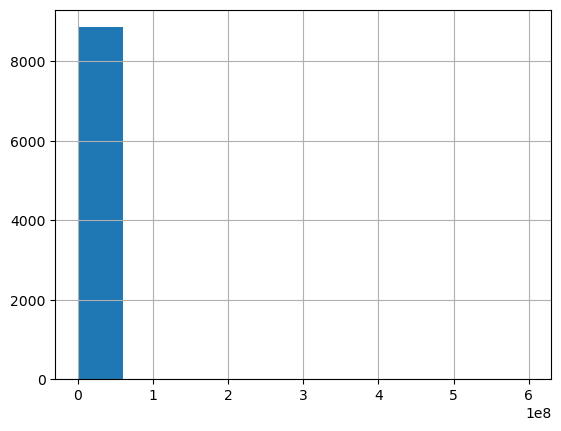

In [37]:
# Checking the skewness of the target value say 'Price'

df['Price'].hist()

In [38]:
df['Price'].describe()

count    8.862000e+03
mean     2.299673e+06
std      7.888376e+06
min      5.000000e+02
25%      5.500000e+05
50%      1.000000e+06
75%      2.500000e+06
max      6.000000e+08
Name: Price, dtype: float64

In [39]:
skewness = df['Price'].skew()
skewness

53.070652631842265

In [40]:
# Log-transform price

df['Price_log'] = np.log1p(df['Price'])
df

,Price,Bedrooms,Locality,Property_type,Area,Is_estate,Price_log
0,400000,1,Ajah,mini flat,island,1,12.899222
1,14000000,3,Ikoyi,flat,island,0,16.454568
2,200000,1,Yaba,mini flat,mainland,0,12.206078
3,800000,2,Surulere,flat,mainland,0,13.592368
4,300000,1,Yaba,mini flat,mainland,0,12.611541
...,...,...,...,...,...,...,...
8857,400000,1,Yaba,mini flat,mainland,0,12.899222
8858,800000,3,Yaba,flat,mainland,0,13.592368
8859,1000000,2,Yaba,flat,mainland,0,13.815512
8860,1500000,3,Ogudu,duplex,mainland,0,14.220976


In [41]:
# Re-check distribution

df['Price_log'].describe()
df['Price_log'].skew()

0.240516107462297

In [94]:
# checking duplicates and 

print(df.duplicated().sum())
df_duplicate=df[df.duplicated()]

5915


In [96]:
df_duplicate

,Price,Bedrooms,Locality,Property_type,Area,Is_estate,Price_log
5,300000,1,Yaba,mini flat,mainland,0,12.611541
15,300000,1,Yaba,mini flat,mainland,0,12.611541
43,600000,3,Yaba,flat,mainland,0,13.304687
46,1200000,3,Yaba,flat,mainland,0,13.997833
50,1200000,3,Yaba,flat,mainland,0,13.997833
...,...,...,...,...,...,...,...
8856,800000,3,Ogudu,flat,mainland,0,13.592368
8857,400000,1,Yaba,mini flat,mainland,0,12.899222
8858,800000,3,Yaba,flat,mainland,0,13.592368
8859,1000000,2,Yaba,flat,mainland,0,13.815512


In [98]:
df_duplicate.iloc[1:60]

,Price,Bedrooms,Locality,Property_type,Area,Is_estate,Price_log
15,300000,1,Yaba,mini flat,mainland,0,12.611541
43,600000,3,Yaba,flat,mainland,0,13.304687
46,1200000,3,Yaba,flat,mainland,0,13.997833
50,1200000,3,Yaba,flat,mainland,0,13.997833
51,1000000,3,Ikosi,flat,mainland,0,13.815512
57,700000,3,Yaba,flat,mainland,0,13.458837
61,800000,3,Yaba,flat,mainland,0,13.592368
62,800000,3,Yaba,flat,mainland,0,13.592368
65,250000,2,Ikorodu,flat,mainland,0,12.429220
67,300000,0,Yaba,self contain,mainland,0,12.611541


In [43]:
#df.to_csv('cleaned_data.csv', index=False)

In [100]:
df.to_csv('cleaned_data_wdc.csv', index=False)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('cleaned_data_wdc.csv')

# 1. Drop duplicates
df = df.drop_duplicates()

# 2. Remove suspicious prices
df = df[df['Price'] >= 50_000]

# 3. Fix locality casing
df['Locality'] = df['Locality'].str.strip().str.title()

# 4. Encode categoricals (for tree models)
for col in ['Locality', 'Property_type', 'Area']:
    df[col] = LabelEncoder().fit_transform(df[col])

# 5. Define features and target
X = df.drop(columns=['Price', 'Price_log'])
y = df['Price_log']  # use this as your target